In [1]:
import numpy as np
import pandas as pd
import scipy.spatial
from scipy.sparse import lil_matrix, csgraph
import geopandas as gpd
import matplotlib.pyplot as plt

import datetime
from tx_fast_hydrology.muskingum import Muskingum, ModelCollection
from tx_fast_hydrology.simulation import AsyncSimulation
from tx_fast_hydrology.io import ModelDecoder, ModelEncoder

# Read data

In [2]:
nhf_path = '/home/akagi/Documents/Data/txswift/nhf_1.1.3.gpkg'
nhd_path = '/home/akagi/Documents/Data/GIS/NHD_H_Texas_State_GDB/NHD_H_Texas_State_GDB.gdb'
nhf_subbasins = gpd.read_file(nhf_path, layer='divides')
nhd_flowlines = gpd.read_file(nhd_path, layer=18)

/home/akagi/.local/lib/python3.11/site-packages/pyogrio/raw.py:196: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured 3D MultiLineString' is converted to 'MultiLineString Z'
  return ogr_read(


# Clip to study area

In [3]:
xmin, ymin, xmax, ymax = nhf_subbasins.to_crs(nhd_flowlines.crs).total_bounds
nhd_flowlines = nhd_flowlines.cx[xmin:xmax, ymin:ymax]
nhd_flowlines = nhd_flowlines.reset_index(drop=True)
geom_array = nhd_flowlines.geometry

In [4]:
# Ensure multilinestrings are actually linestrings
assert max(geom_array.apply(lambda x: len(x.geoms)).values) == 1

# Create and query spatial index of start and end points of flowlines

In [5]:
coords = geom_array.apply(lambda x: x.geoms[0]).apply(lambda y: y.coords.xy)
x = coords.str[0]
y = coords.str[1]
x0, x1 = x.str[0], x.str[-1]
y0, y1 = y.str[0], y.str[-1]
p0 = np.column_stack([x0.values, y0.values])
p1 = np.column_stack([x1.values, y1.values])
xy = np.column_stack([np.concatenate(x.values), np.concatenate(y.values)])

p0_indices = np.asarray([0] + x.str.len().cumsum().values.tolist()[:-1])
p1_indices = (x.str.len().cumsum() - 1).values
radius = 4
threshold = 0.

tree = scipy.spatial.KDTree(xy)
arr_lens = x.apply(lambda x: len(x))
point_indices = np.repeat(arr_lens.index.values, arr_lens.values)
start_dists, start_indices = tree.query(p0, k=radius)
end_dists, end_indices = tree.query(p1, k=radius)

# Connect upstream ends based on proximity

In [6]:
starts = point_indices[start_indices]
upstream = {}
upstream_points = {}
upstream_dists = {}
upstream_failed = []

for i in range(p0.shape[0]):
    upstream[i] = []
    upstream_points[i] = []
    upstream_dists[i] = []
    for j in range(radius):
        if start_dists[i,j] <= threshold:
            if starts[i,j] != i:
                upstream[i].append(starts[i,j])
                upstream_points[i].append(start_indices[i,j])
                upstream_dists[i].append(start_dists[i,j])
    if not upstream[i]:
        upstream_failed.append(i)

In [7]:
print(f'{len(upstream_failed)} upstream connections unmatched')

53153 upstream connections unmatched


# Connect downstream ends based on proximity

In [8]:
ends = point_indices[end_indices]
downstream = {}
downstream_points = {}
downstream_dists = {}
downstream_failed = []

for i in range(p1.shape[0]):
    downstream[i] = []
    downstream_points[i] = []
    downstream_dists[i] = []
    for j in range(radius):
        if end_dists[i,j] <= threshold:
            if ends[i, j] != i:
                downstream[i].append(ends[i,j])
                downstream_points[i].append(end_indices[i,j])
                downstream_dists[i].append(end_dists[i,j])
    if not downstream[i]:
        downstream_failed.append(i)

In [9]:
print(f'{len(downstream_failed)} downstream connections unmatched')

1193 downstream connections unmatched


# Check connectivity

In [10]:
n = nhd_flowlines.shape[0]
adj = lil_matrix((n, n), dtype=int)
nodes = np.arange(n)
for i in nodes:
    j = upstream[i]
    k = downstream[i]
    if j:
        for jj in j:
            adj[i, jj] = 1
            adj[jj, i] = 1
    if k:
        for kk in k:
            adj[kk, i] = 1
            adj[i, kk] = 1

In [11]:
num_components, labels = csgraph.connected_components(adj,
                                                      directed=True,
                                                      connection='weak')

In [12]:
num_components

1240

# Create reach-to-reach mapping for Trinity

In [13]:
trinity_outlet = '93945390'
trinity_outlet_index = nhd_flowlines[nhd_flowlines['permanent_identifier'] == trinity_outlet].index.item()

nhd_flowlines['id'] = nhd_flowlines.index

In [14]:
dist, pred = csgraph.shortest_path(adj, return_predecessors=True, indices=trinity_outlet_index)

In [15]:
nhd_flowlines['to_id'] = [nhd_flowlines.loc[j, 'id'] if j != -9999 else nhd_flowlines.loc[i, 'id'] for i, j in zip(nodes, pred)]
nhd_flowlines['labels'] = labels

In [16]:
trinity = nhd_flowlines[nhd_flowlines['id'] != nhd_flowlines['to_id']]
trinity = pd.concat([trinity, nhd_flowlines.loc[[trinity_outlet_index]]], axis=0)

id_mapping = pd.Series(np.arange(len(trinity)), index=trinity['id'])
trinity.index = id_mapping.values
trinity['id'] = id_mapping.loc[trinity['id']].values
trinity['to_id'] = id_mapping.loc[trinity['to_id']].values

<Axes: >

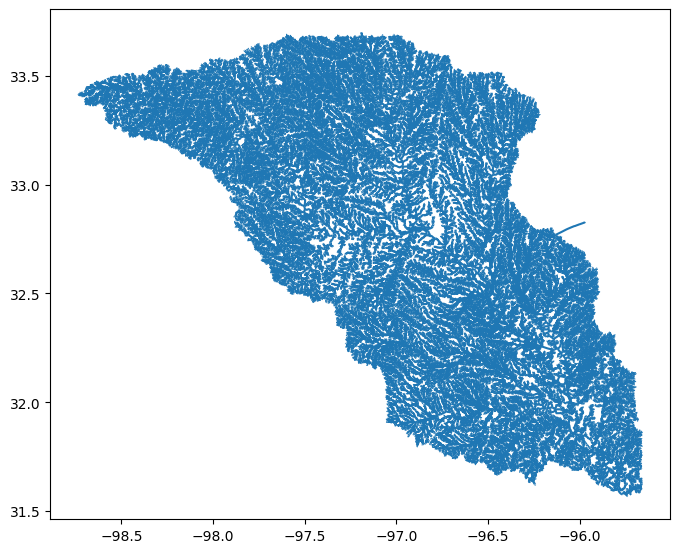

In [17]:
fig, ax = plt.subplots(figsize=(8, 8))
trinity.plot(column='labels', cmap='tab10', ax=ax)

# Prepare Muskingum model input data

In [18]:
name = 'trinity'
start_date = pd.to_datetime('2026-01-01T00:00:00', utc=True)
reach_ids = trinity['id'].astype(str).values
to_reach_ids = trinity['to_id'].fillna(-1).astype(int).astype(str).values

In [19]:
dx = (trinity['lengthkm'] * 1000).values

In [20]:
min_dt = 15.
min_K = min_dt / 2 / (1 - 0.29)
K = (dx / 2.12)

Text(0.5, 0, 'Travel time [s]')

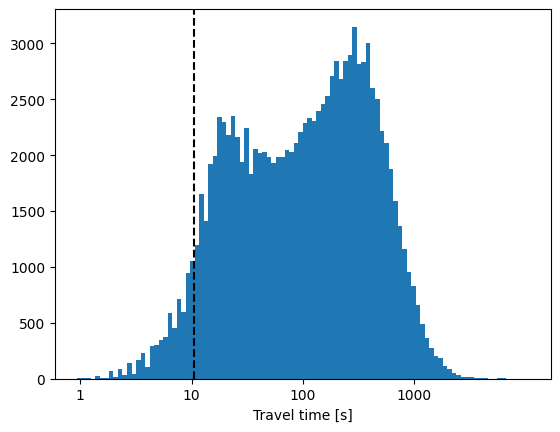

In [21]:
fig, ax = plt.subplots()
_ = ax.hist(np.log10(K), bins=100)
plt.axvline(np.log10(min_K), linestyle='--', c='k')
ax.xaxis.set_ticks([0, 1, 2, 3])
ax.xaxis.set_ticklabels(['1', '10', '100', '1000'])
plt.xlabel('Travel time [s]')

In [22]:
# Establish drainage network topology
reach_index = pd.Series(trinity.index.values, index=reach_ids)
startnodes = reach_index.reindex(reach_ids, fill_value=-1).values
endnodes = reach_index.reindex(to_reach_ids, fill_value=-1).values
self_loops = []
for i in range(len(startnodes)):
    if endnodes[i] == -1:
        self_loops.append(i)
        endnodes[i] = startnodes[i]

# Specify parameters
K = np.maximum(K, 1.5 * min_K)
X = 0.29 * np.ones(trinity.shape[0], dtype=np.float64)                     # Attenuation parameter [-]
o_t = 0. * np.ones(trinity.shape[0], dtype=np.float64)                     # Initial outflow from each reach [m^3/s]

# Process flowpath geometries
linestring_geoms = trinity.geometry.apply(lambda x: x.geoms[0])            # Note: this flattens multilinestrings
paths = (linestring_geoms.apply(lambda x: [np.column_stack(x.xy)])
         .values.tolist())

# Apply initial flow to headwaters only
#indegree = np.bincount(endnodes, minlength=len(startnodes))[startnodes]
#o_t[indegree == 0] = 1.

In [23]:
timedelta = pd.to_timedelta(min_dt, unit='s')

In [24]:
wbd = nhf_subbasins.set_index('div_id').loc[518537]
wbd_geom = wbd.geometry
flowlines_selection = trinity[trinity.to_crs(nhf_subbasins.crs).within(wbd_geom)]
per_reach_area_approx = wbd_geom.area * flowlines_selection['lengthkm'] / flowlines_selection['lengthkm'].sum()

<Axes: >

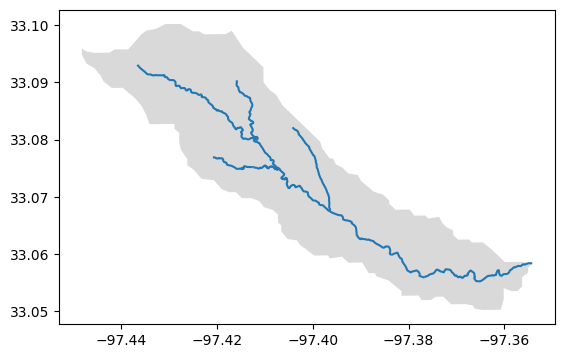

In [25]:
fig, ax = plt.subplots()

nhf_subbasins.to_crs(flowlines_selection.crs).set_index('div_id').loc[[518537]].plot(ax=ax, facecolor='0.85')
flowlines_selection.plot(ax=ax)

In [26]:
ddf_table = pd.read_csv('../data/Atlas_14_Dallas.csv', skiprows=13, skipfooter=2, index_col=0)
ddf_table__m = ddf_table / 39.37
ddf_table__m

/tmp/ipykernel_132280/473877603.py:1: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support skipfooter; you can avoid this warning by specifying engine='python'.
  ddf_table = pd.read_csv('../data/Atlas_14_Dallas.csv', skiprows=13, skipfooter=2, index_col=0)


,1,2,5,10,25,50,100,200,500,1000
by duration for ARI (years):,,,,,,,,,,
5-min:,0.010668,0.012421,0.015316,0.017704,0.020955,0.023419,0.025908,0.028448,0.032004,0.034544
10-min:,0.017069,0.019914,0.024562,0.028448,0.033528,0.037592,0.041656,0.045720,0.050800,0.054864
15-min:,0.021285,0.024765,0.030480,0.035306,0.041656,0.046482,0.051308,0.056388,0.063246,0.068580
30-min:,0.029718,0.034290,0.042164,0.048768,0.057404,0.064008,0.070866,0.077724,0.087376,0.094996
60-min:,0.038354,0.044704,0.055118,0.063754,0.075438,0.084328,0.093218,0.102870,0.116332,0.127000
2-hr:,0.046990,0.055372,0.068834,0.080264,0.096012,0.108204,0.120904,0.134620,0.153924,0.169418
3-hr:,0.051816,0.061468,0.077216,0.090424,0.108966,0.123698,0.139192,0.155956,0.179324,0.198120
6-hr:,0.060960,0.073152,0.092202,0.108712,0.132334,0.151130,0.171196,0.193040,0.223520,0.248158
12-hr:,0.071120,0.085852,0.108712,0.128270,0.156718,0.179070,0.203200,0.229362,0.266701,0.297181


In [27]:
intensities = ddf_table__m.loc['3-hr:'] / (3 * 3600)

# Package model instance data into dictionary

In [28]:
data = {
    'name' : name,
    'datetime' : start_date,
    'timedelta' : timedelta,
    'reach_ids' : reach_ids,
    'startnodes' : startnodes,
    'endnodes' : endnodes,
    'K' : K,
    'X' : X,
    'o_t' : o_t,
    'dx' : dx,
    'paths' : paths
}

# Instantiate Muskingum model

In [29]:
all_outputs = {}

for return_period, intensity in zip(intensities.index, intensities.values):
    print(return_period)
    model = Muskingum(data)
    p_t_next = np.zeros(model.n)
    p_t_next[flowlines_selection.index.values] = intensity * per_reach_area_approx.values

    model.init_states(o_t_next=o_t)

    outputs = {}
    outputs[model.datetime] = model.o_t_next

    for _ in range(4 * 24 * 7):
        model.step(p_t_next)
        outputs[model.datetime] = model.o_t_next
    ref_outputs = pd.DataFrame.from_dict(outputs, orient='index')
    ref_outputs.columns = model.reach_ids
    ref_outputs.index = pd.to_datetime(ref_outputs.index, utc=True)
    all_outputs[return_period] = ref_outputs

 1
2
5
10
25
50
100
200
500
1000


# Plot streamflow output

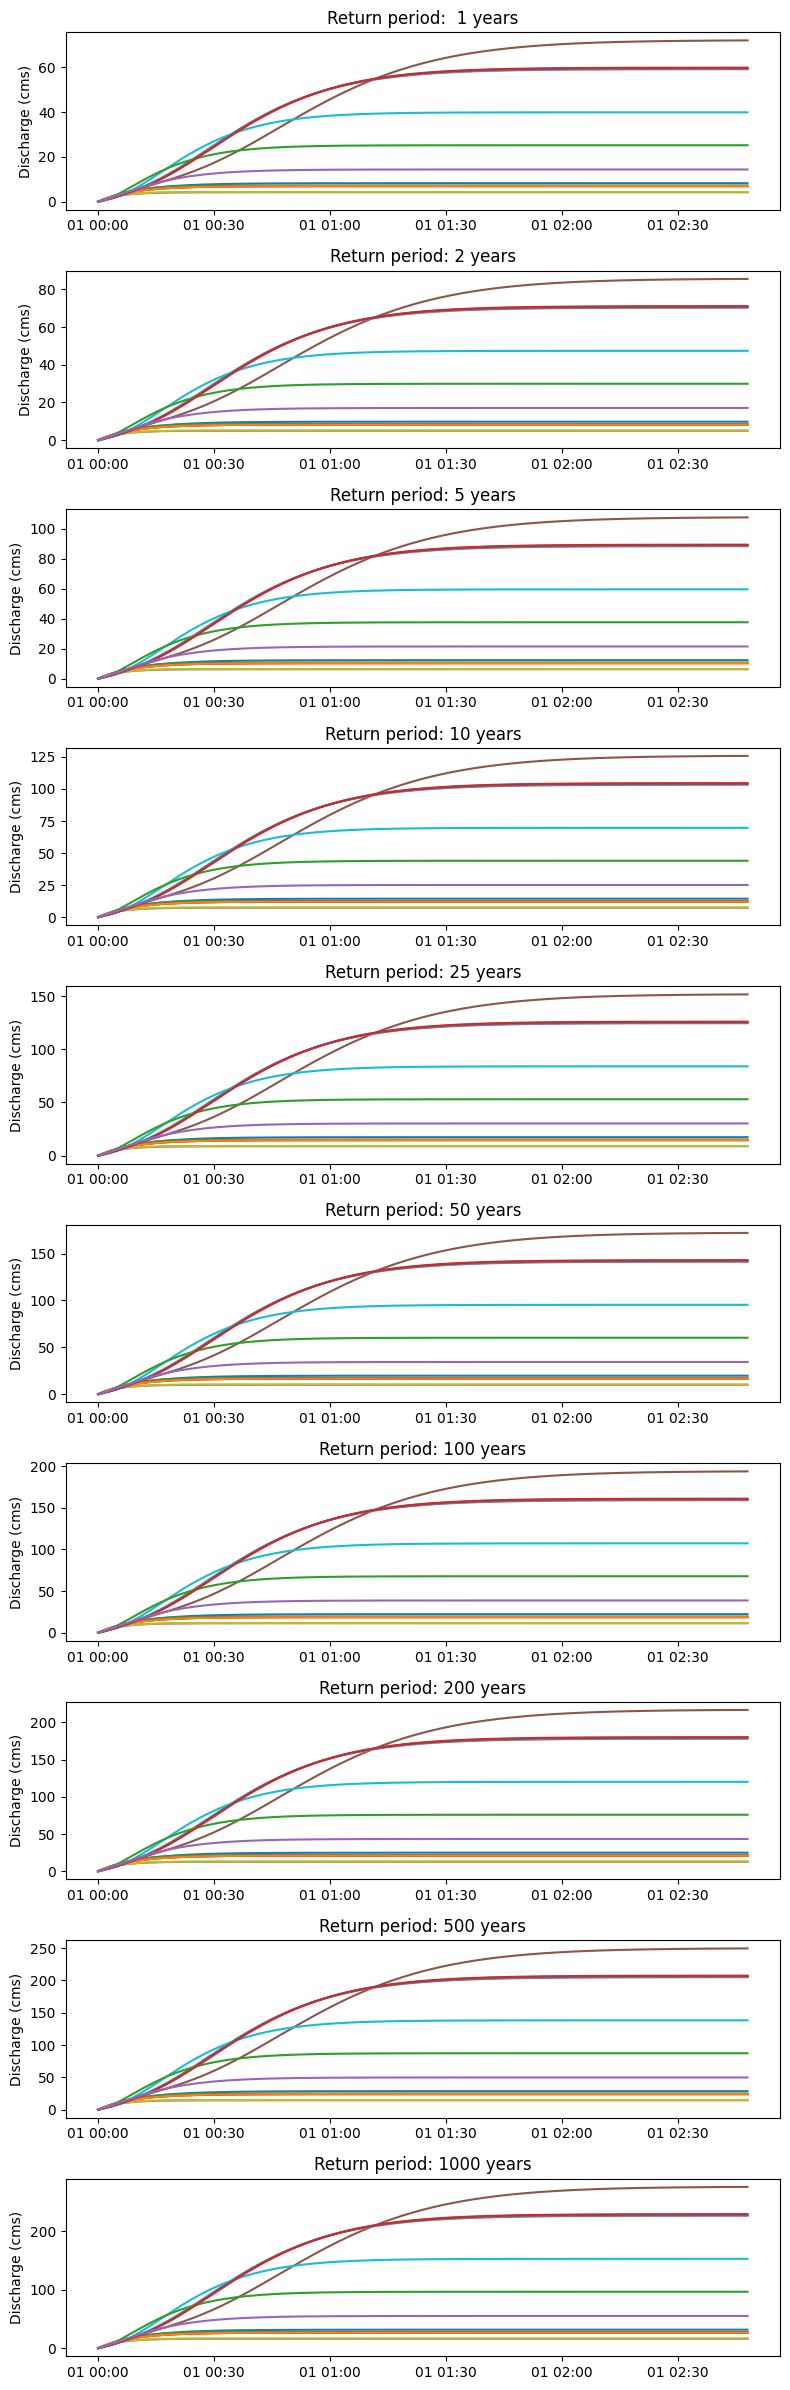

In [30]:
fig, ax = plt.subplots(len(all_outputs), figsize=(8, 24))
i = 0
for return_period, output in all_outputs.items():
    _ = ax.flat[i].plot(output.index, output[flowlines_selection.index.astype(str)].values)
    ax.flat[i].set_ylabel('Discharge (cms)')
    ax.flat[i].set_xlabel('')
    ax.flat[i].set_title(f'Return period: {return_period} years')
    i += 1

plt.tight_layout()

In [31]:
wbd_geom.area * intensities

 1       72.197103
2        85.645583
5       107.587840
10      125.991023
25      151.826261
50      172.352888
100     193.941238
200     217.299124
500     249.858602
1000    276.047747
Name: 3-hr:, dtype: float64